In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
import seaborn as sns
from scipy.stats import kurtosis
from scipy.stats import skew

In [38]:
# Step 1: Load the datasets
color_class_0 = pd.read_csv("dataset/graycomatrix_image_analysis_class_0_color.csv")
color_class_1 = pd.read_csv("dataset/graycomatrix_image_analysis_class_1_color.csv")


# Step 2: Add class labels to each dataset
color_class_0['target'] = 0  # Label for class 0
color_class_1['target'] = 1  # Label for class 1

# Step 3: Concatenate the datasets and shuffle
df_color= pd.concat([color_class_0, color_class_1], ignore_index=True)
#df_combined = df_combined.sample(frac=1, random_state=42).reset_index(drop=True)  # Shuffle rows

df_color= df_combined.sample(frac=1, random_state=142).reset_index(drop=True)  # Shuffle rows


In [39]:
df_color.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186 entries, 0 to 185
Columns: 798 entries, image_name to target
dtypes: float64(796), int64(1), object(1)
memory usage: 1.1+ MB


In [40]:
# Drop morphological features from original_df
hist_features = [col for col in df_combined.columns if col.startswith("hist_")]
filtered_df_color = df_combined.drop(columns=hist_features)
filtered_df_color

,image_name,mean_r,mean_g,mean_b,std_r,std_g,std_b,gabor_0,gabor_1,gabor_2,...,gabor_13,gabor_14,gabor_15,mean_intensity,std_intensity,min_intensity,max_intensity,skewness,kurtosis,target
0,12893_idx5_x351_y1801_class1.png,167.4544,124.8756,162.3536,24.898705,26.955551,19.625080,0.034570,0.000330,0.001242,...,0.006050,0.212517,0.002056,0.535787,0.100166,0.272116,0.838382,0.000134,0.000246,1
1,12893_idx5_x1351_y1001_class0.png,230.0888,199.9288,212.1168,14.058368,32.939176,24.758077,0.052432,0.000276,0.001885,...,0.008357,0.322311,0.002482,0.812614,0.109447,0.336593,0.958820,-0.000993,0.000459,0
2,12893_idx5_x1251_y1351_class1.png,182.6880,144.7208,177.3580,27.473075,35.154454,24.338616,0.039255,0.000628,0.001411,...,0.010340,0.241319,0.003193,0.608400,0.126972,0.313519,0.934167,0.000864,0.000665,1
3,12893_idx5_x451_y501_class0.png,231.5360,209.4024,218.9104,18.702340,36.713034,26.913505,0.054348,0.000321,0.001953,...,0.013103,0.334103,0.002766,0.842319,0.124529,0.224217,0.959951,-0.002588,0.001246,0
4,12893_idx5_x1201_y1251_class0.png,216.2940,169.4696,191.2992,19.850893,25.859178,19.148913,0.045797,0.000288,0.001647,...,0.005361,0.281528,0.001750,0.709779,0.091913,0.279982,0.934717,-0.000544,0.000369,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181,12893_idx5_x1001_y2201_class1.png,162.0972,128.4984,162.8968,34.375976,44.444919,31.940340,0.034948,0.000677,0.001258,...,0.019874,0.214825,0.004781,0.541640,0.160497,0.095126,0.928556,0.002473,0.001928,1
182,12893_idx5_x751_y1201_class0.png,217.6776,171.1628,192.6880,20.881151,24.755304,18.265888,0.046203,0.000176,0.001661,...,0.005402,0.284023,0.001659,0.716075,0.089348,0.272675,0.941727,-0.001135,0.000531,0
183,12893_idx5_x1051_y1051_class0.png,213.4796,157.9844,181.4744,20.565485,32.529460,24.445542,0.043387,0.000273,0.001559,...,0.009186,0.266708,0.002395,0.672434,0.111215,0.321646,0.947881,0.001105,0.000572,0
184,12893_idx5_x1401_y1601_class1.png,173.5524,137.3712,171.1248,35.021343,42.687785,30.402362,0.037320,0.000593,0.001342,...,0.017470,0.229415,0.004781,0.578405,0.156510,0.246660,0.926591,0.000189,0.001123,1


In [41]:
# Step 1: Load the datasets
gray_class_0 = pd.read_csv("dataset/graycomatrix_image_analysis_class_0.csv")
gray_class_1 = pd.read_csv("dataset/graycomatrix_image_analysis_class_1.csv")


# Step 2: Add class labels to each dataset
gray_class_0['target'] = 0  # Label for class 0
gray_class_1['target'] = 1  # Label for class 1

# Step 3: Concatenate the datasets and shuffle
df_gray = pd.concat([gray_class_0, gray_class_1], ignore_index=True)

df_gray = df_gray.sample(frac=1, random_state=142).reset_index(drop=True)  # Shuffle rows


In [42]:
df_gray.shape

(186, 32)

In [44]:
# Merge the summarized morphological stats
merged_df = df_gray.merge(filtered_df_color, left_index=True, right_index=True)

# Save merged dataframe
#merged_df.to_csv("merged_features_histo_images.csv")

print("Merged DataFrame shape:", merged_df.shape)

Merged DataFrame shape: (186, 62)


In [66]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186 entries, 0 to 185
Data columns (total 62 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        186 non-null    object 
 1   GLCM_Contrast     186 non-null    float64
 2   GLCM_Correlation  186 non-null    float64
 3   GLCM_Energy       186 non-null    float64
 4   GLCM_Homogeneity  186 non-null    float64
 5   LBP_0             186 non-null    float64
 6   LBP_1             186 non-null    float64
 7   LBP_2             186 non-null    float64
 8   LBP_3             186 non-null    float64
 9   LBP_4             186 non-null    float64
 10  LBP_5             186 non-null    float64
 11  LBP_6             186 non-null    float64
 12  LBP_7             186 non-null    float64
 13  LBP_8             186 non-null    float64
 14  LBP_9             186 non-null    float64
 15  LBP_10            186 non-null    float64
 16  LBP_11            186 non-null    float64
 1

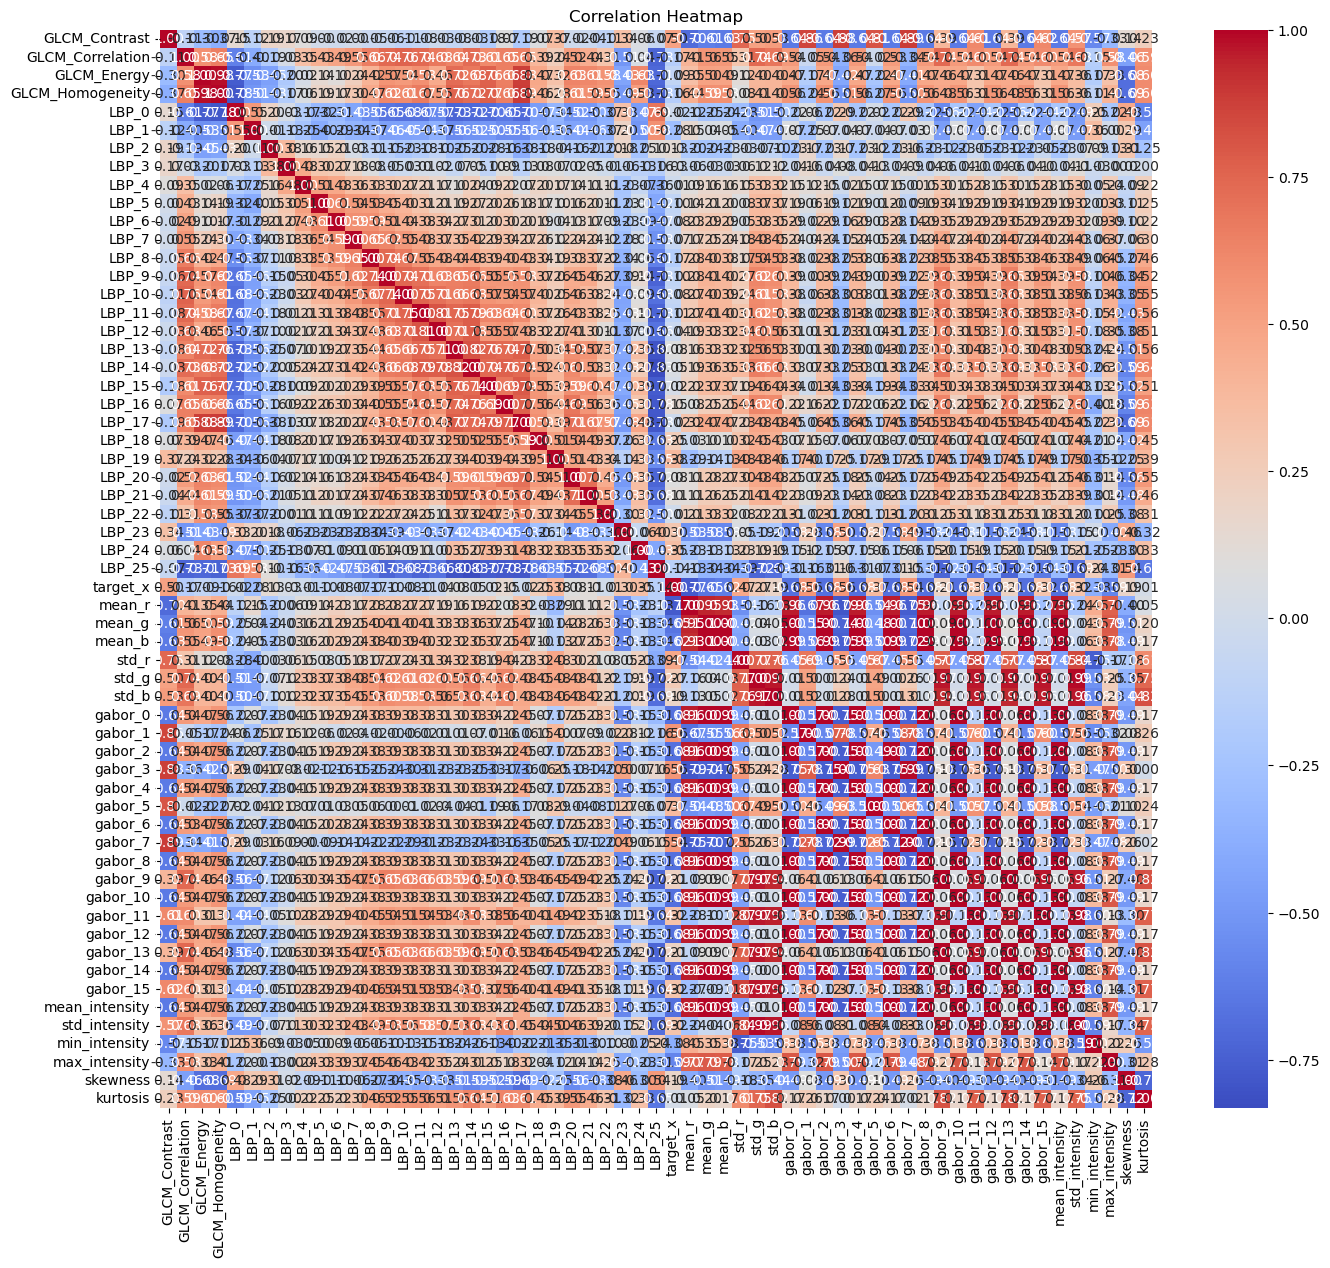

In [50]:
df_excluded = merged_df.drop(columns=['target_y', 'image_name', 'Unnamed: 0'])
#num_cols = [cols for cols in df_excluded.columns if df_excluded[cols].dtype in ['int64', 'float64']]

correlation_matrix = df_excluded.corr()
plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


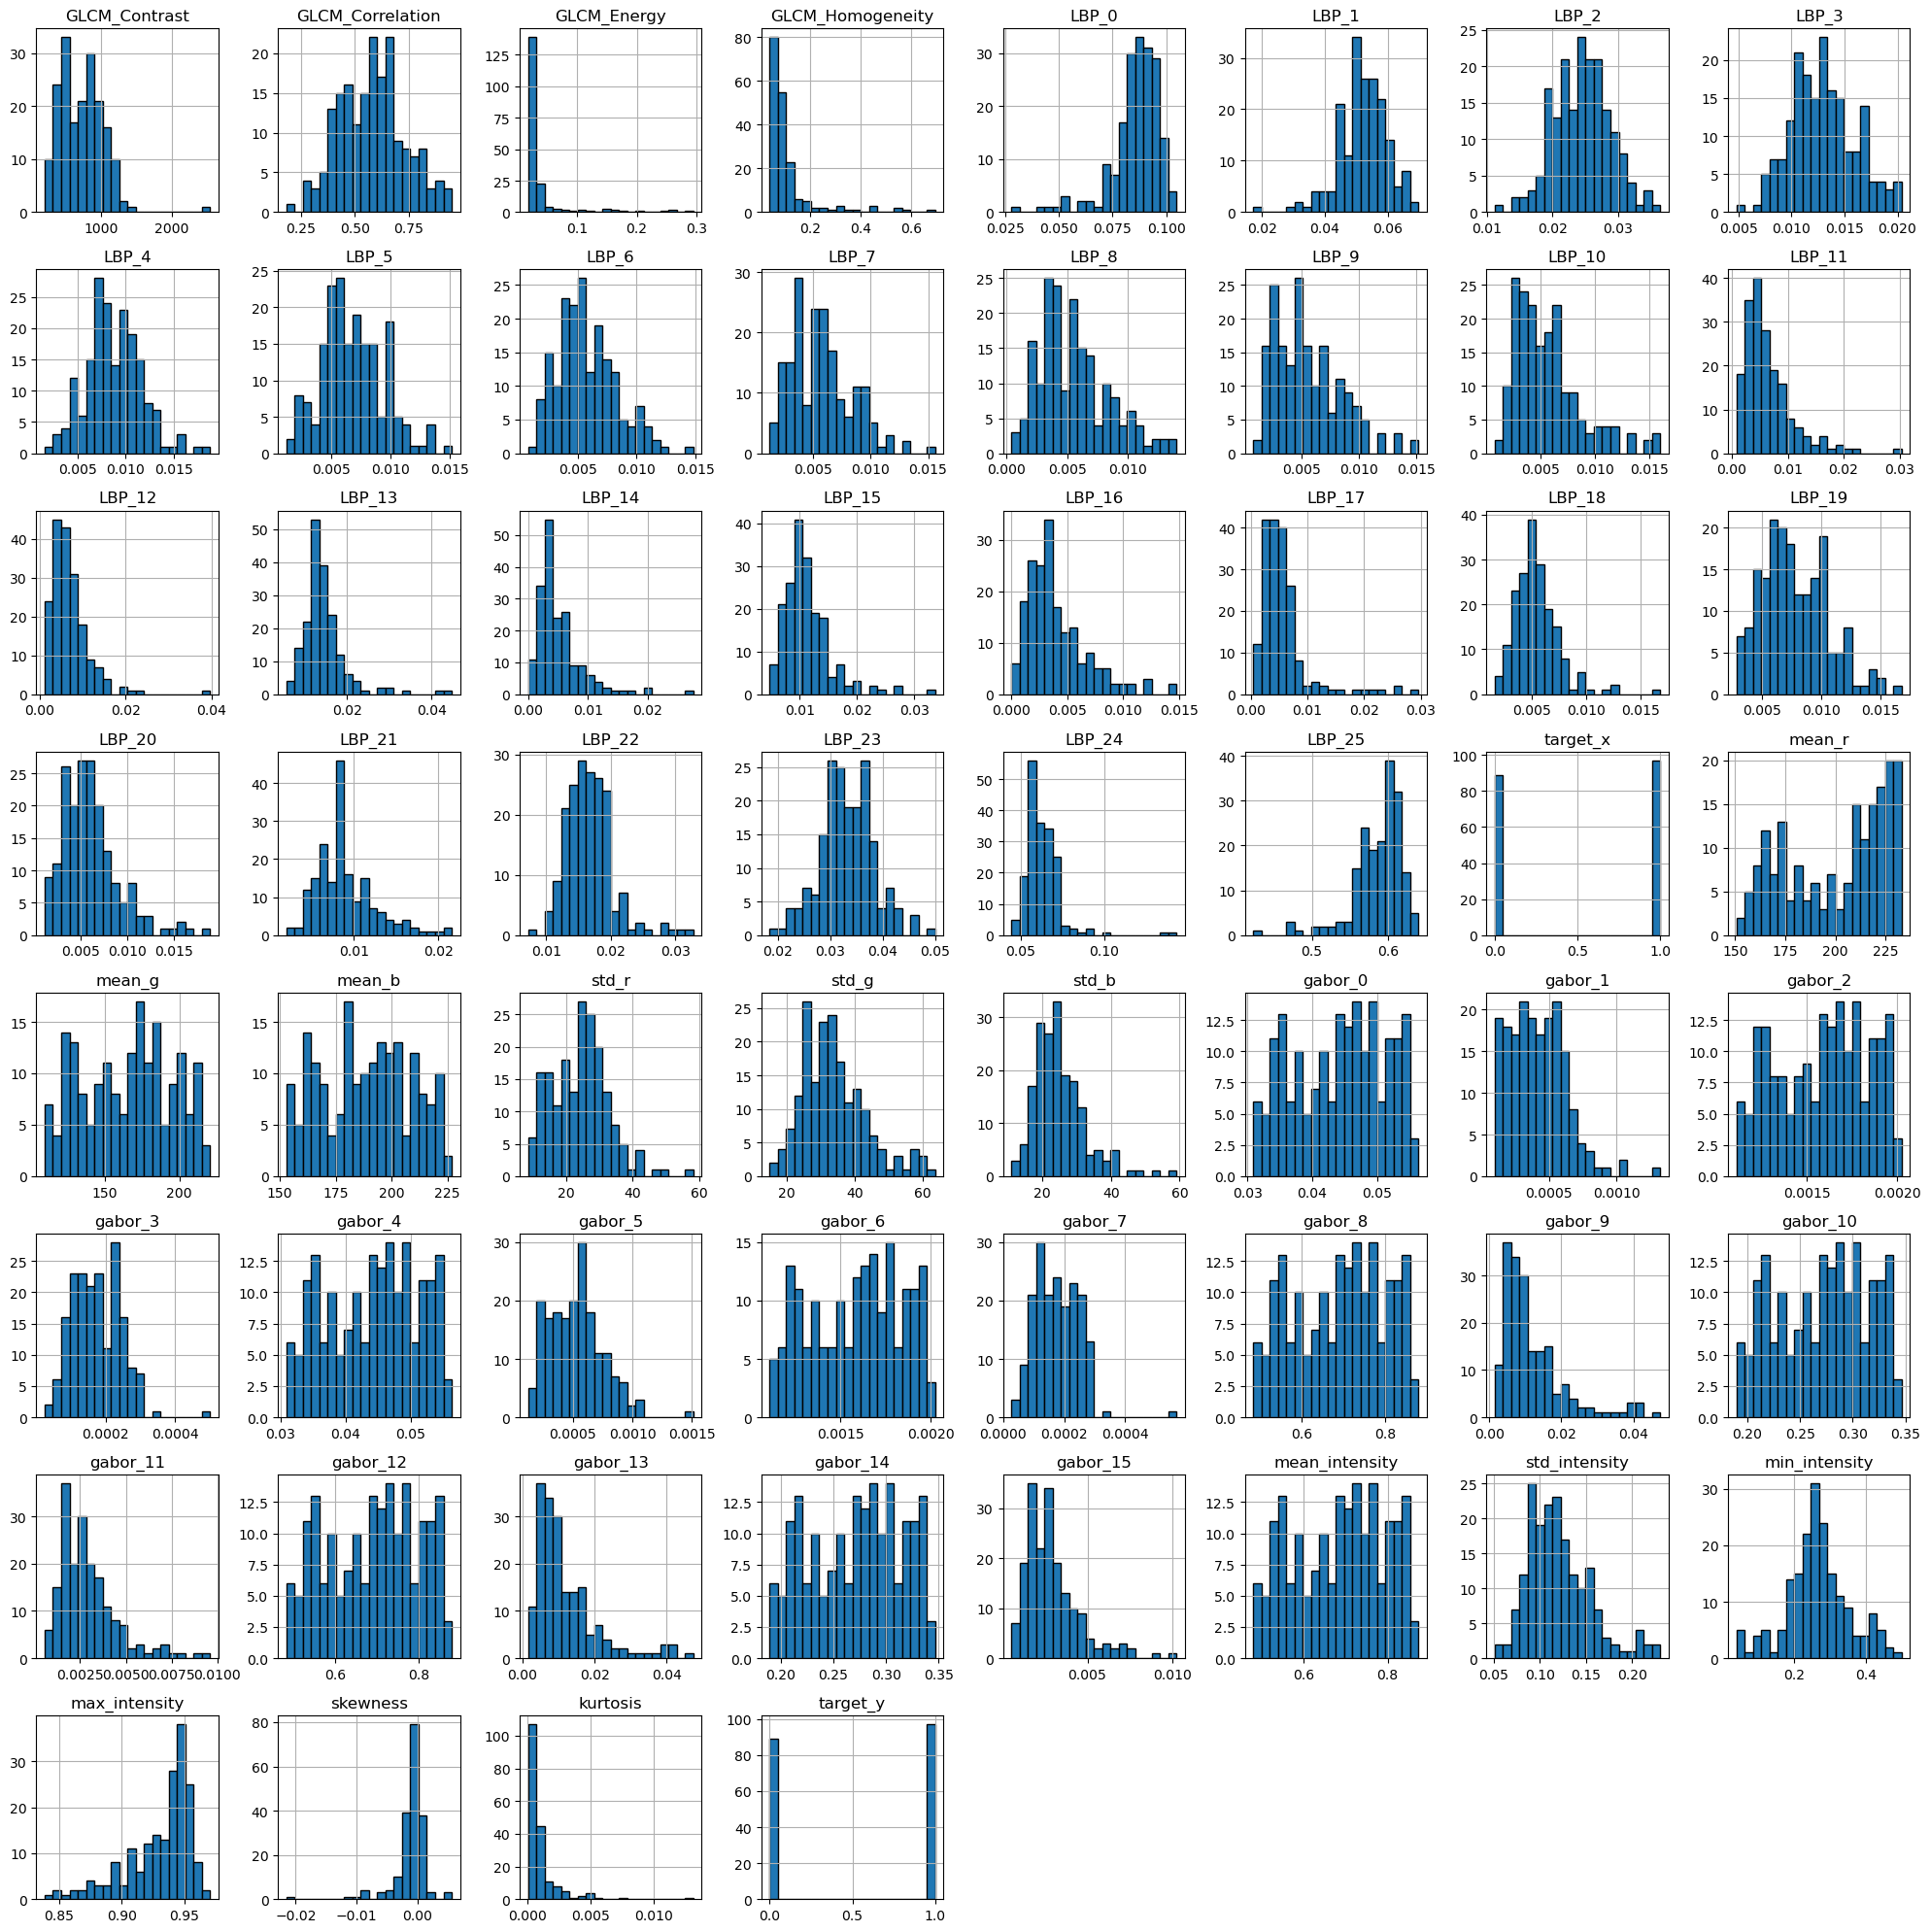

In [51]:
# Check distribution of values
merged_df.hist(figsize=(20, 20), bins=20, edgecolor="black")
plt.tight_layout()
plt.show()

In [69]:
X = merged_df.drop(columns=['target_y', 'image_name', 'Unnamed: 0', 'target_x'])  # Features
y = merged_df['target_x']  # Target labels

# Step 5: Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [70]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

# Train Random Forest to find important features
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Select features with importance above a threshold
selector = SelectFromModel(rf, prefit=True, threshold='median')  # Keep median importance
X_train_reduced = selector.transform(X_train)
X_test_reduced = selector.transform(X_test)

/Users/solozobovavaleria/anaconda3/lib/python3.11/site-packages/sklearn/base.py:457: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
/Users/solozobovavaleria/anaconda3/lib/python3.11/site-packages/sklearn/base.py:457: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Accuracy: 0.868421052631579

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.83      0.86        18
           1       0.86      0.90      0.88        20

    accuracy                           0.87        38
   macro avg       0.87      0.87      0.87        38
weighted avg       0.87      0.87      0.87        38

ROC-AUC Score: 0.9152777777777779
[[15  3]
 [ 2 18]]


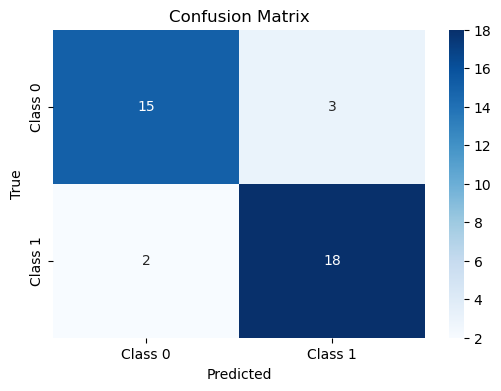

In [74]:
# Step 6: Train the Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=200, random_state=142)
rf_model.fit(X_train_reduced, y_train)

# Step 7: Make predictions on the test set
y_pred = rf_model.predict(X_test_reduced)
y_pred_proba = rf_model.predict_proba(X_test_reduced)[:, 1]

# Step 8: Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))


# Step 9: Generate a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


In [75]:
from sklearn.decomposition import PCA

# Reduce to 20 components
pca = PCA(n_components=20)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Check explained variance
print("Explained variance ratio:", pca.explained_variance_ratio_)

Explained variance ratio: [9.87992431e-01 1.05886050e-02 9.83111041e-04 3.10816123e-04
 9.28893472e-05 2.92377104e-05 2.81407883e-06 3.80420433e-08
 2.78534568e-08 2.32840041e-08 2.40698935e-09 1.34653901e-09
 4.55309151e-10 3.27768435e-10 2.70919210e-10 2.15954436e-10
 1.56710196e-10 1.32199543e-10 1.09150589e-10 7.76059323e-11]
